# Notebook 4
# Dispatcher, Methodik, OOD, Abweichungsprüfung

Themen:
- 10 Dispatcher: welche Config gewinnt bei welchem Workload
- 11 Pre-Flight Methodik: die operative Regel gegen Negativ-Komposition
- 12 OOD-Validierung auf c1024_56gb: reproduziert das Muster bei anderer Density?
- 13 Abweichungsprüfung: welche Grenzfall-Claims überleben die 5-rep CIs?


In [7]:
# bench.db loading setup
import sqlite3
import re
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Hier noch den path ändern, falls bench.db woanders liegt
DB_PATH = Path('../../logs/bench.db')
assert DB_PATH.exists(), f'bench.db not found at {DB_PATH.resolve()}'

with sqlite3.connect(DB_PATH) as _conn:
    raw = pd.read_sql_query('SELECT * FROM runs', _conn)

print(f'loaded {len(raw):,} rows across {raw.build.nunique()} builds, '
      f'{raw.threads.nunique()} thread counts, {raw.label.nunique()} labels')

loaded 2,555 rows across 54 builds, 15 thread counts, 97 labels


In [8]:
# Helferfunktionen für die Analyse der Benchmarks

def parse_dataset(label):
    """Map a bench.db `label` string to a canonical dataset name."""
    if label.startswith('ood_') or 'c1024' in label:
        return 'c1024_56gb'
    if label.startswith('variance_'):
        return 'c256_56gb'
    # Fine-t sweep experiments für c256_56gb
    if label.startswith('lennart_c256_56gb_') or label.startswith('lennart_56gb_'):
        return 'c256_56gb'
    m = re.match(r'(?:main|numa)_(\d+gb)_', label)
    return f'c256_{m.group(1)}' if m else None

raw['dataset'] = raw['label'].apply(parse_dataset)

def q(*, builds=None, threads=None, dataset=None, suppress=True, agg='median'):
    """Slice the runs table by (build, threads, dataset) and aggregate over reps.

    Returns one row per (build, threads) with median wall_s + mean counters.
    """
    df = raw.copy()
    if suppress is not None:
        df = df[df.suppress_results == int(suppress)]
    if builds is not None:
        df = df[df.build.isin(builds if isinstance(builds, (list, tuple)) else [builds])]
    if threads is not None:
        df = df[df.threads.isin(threads if isinstance(threads, (list, tuple)) else [threads])]
    if dataset is not None:
        df = df[df.dataset == dataset]
    if df.empty:
        return df
    metrics = ['wall_s', 'ipc', 'l1_misses', 'llc_misses', 'llc_bw_gbs', 'branch_misses']
    g = df.groupby(['build', 'threads'])
    out = g[metrics].median() if agg == 'median' else g[metrics].mean()
    out['n_reps'] = g.size()
    return out.reset_index().sort_values(['build', 'threads'])

def compare(baseline, ablation, *, threads, dataset, suppress=True):
    """Side-by-side wall + IPC + LLC-miss for baseline vs ablation across t."""
    base = q(builds=[baseline], threads=threads, dataset=dataset, suppress=suppress)
    abl = q(builds=[ablation], threads=threads, dataset=dataset, suppress=suppress)
    if base.empty or abl.empty:
        return pd.DataFrame()
    m = base[['threads','wall_s','ipc','llc_misses']].merge(
        abl[['threads','wall_s','ipc','llc_misses']],
        on='threads', suffixes=(f'_{baseline}', f'_{ablation}'))
    m['ratio_wall'] = m[f'wall_s_{ablation}'] / m[f'wall_s_{baseline}']
    m['delta_ipc'] = m[f'ipc_{ablation}'] - m[f'ipc_{baseline}']
    return m

def ci95(series):
    """5-rep 95% CI half-width via Welch-style t(4) ≈ 2.776."""
    import statistics, math
    n = len(series)
    if n < 2:
        return 0.0
    sd = statistics.stdev(series)
    return 2.776 * sd / math.sqrt(n)

def delta_ci(baseline_walls, ablation_walls):
    """Return (mean_delta_pct, ci95_pct_half) for ablation vs baseline."""
    import statistics, math
    n_a, n_b = len(baseline_walls), len(ablation_walls)
    m_a, m_b = statistics.mean(baseline_walls), statistics.mean(ablation_walls)
    sd_a = statistics.stdev(baseline_walls) if n_a > 1 else 0
    sd_b = statistics.stdev(ablation_walls) if n_b > 1 else 0
    diff = m_b - m_a
    se = math.sqrt(sd_a**2/n_a + sd_b**2/n_b)
    half = 2.776 * se
    return 100*diff/m_a, 100*half/m_a

def datasets_available():
    return raw[raw.dataset.notna()].groupby('dataset').agg(
        n_rows=('id','count'), n_builds=('build','nunique'),
        threads=('threads', lambda s: sorted(s.unique())))

print('helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()')
datasets_available()

helpers loaded: q(), compare(), ci95(), delta_ci(), parse_dataset(), datasets_available()


,n_rows,n_builds,threads
dataset,,,
c1024_56gb,426,16,"[1, 8, 16, 32, 48, 64, 96]"
c256_10gb,693,20,"[1, 8, 16, 32, 64, 96]"
c256_30gb,546,19,"[1, 8, 16, 32, 64, 96]"
c256_56gb,890,34,"[1, 8, 12, 14, 16, 18, 20, 24, 28, 32, 48, 64,..."


## 10. Der Dispatcher

Statt eine `bestofsuite` Config auf alle Workloads zu werfen, wählt der Dispatcher aus einer Regime-Best Menge basierend auf zwei einfachen Workload-Statistiken:
- `n_hists`: Gesamtzahl Histogramme
- `n_clusters` (K_effective): Anzahl effektive Cluster

Daraus abgeleitet: `hists_per_cluster = n_hists / n_clusters` (Density-Parameter).

Die Regel (`fainder/execution/dispatch.py`):

```python
if hists_per_cluster >= 10_000:
    return 'bestofsuite'   # L3-Druck relevant, f16 zahlt sich aus
elif n_hists >= 600_000:
    return 'pooled'        # Allocator-Druck relevant, aber nicht L3
else:
    return 'default'       # klein genug dass keine Decke bindet
```

Exakte Boundaries gefittet aus dem in-distribution Sweep. In JSON-Konfig, auf neuer Hardware neu kalibrierbar ohne Code-Änderung.


In [9]:
# Dispatch Policy — Mirror von fainder/execution/dispatch.py::select_engine
# Reproduziert die Regel inline damit die Zelle in isolierter Analyse ohne Fainder Import läuft.

def recommend(n_hists, n_clusters):
    # Empfohlener build für den Workload beschrieben durch (n_hists, n_clusters)
    hists_per_cluster = n_hists / n_clusters
    if hists_per_cluster >= 10_000:
        return 'bestofsuite'
    elif n_hists >= 600_000:
        return 'pooled'
    else:
        return 'default'

# Test auf die vier bekannten Datasets (Definition inline damit dieses Notebook eigenständig ist)
ds_summary = pd.DataFrame({
    'dataset':       ['c256_10gb', 'c256_30gb', 'c256_56gb', 'c1024_56gb'],
    'histograms':    [323_719, 996_632, 5_017_619, 5_017_619],
    'k_effective':   [129, 184, 191, 610],
    'hists_per_cluster': [2_510, 5_420, 26_300, 8_200],
})

print('=== Recommend() für die vier Datasets ===')
for _, row in ds_summary.iterrows():
    rec = recommend(row['histograms'], row['k_effective'])
    print(f'  {row["dataset"]:15s}  n_hists={row["histograms"]:>10,d}  '
          f'k_eff={row["k_effective"]:>4d}  hists/cluster={row["hists_per_cluster"]:>6,d}  '
          f'→ {rec}')


=== Recommend() für die vier Datasets ===
  c256_10gb        n_hists=   323,719  k_eff= 129  hists/cluster= 2,510  → default
  c256_30gb        n_hists=   996,632  k_eff= 184  hists/cluster= 5,420  → pooled
  c256_56gb        n_hists= 5,017,619  k_eff= 191  hists/cluster=26,300  → bestofsuite
  c1024_56gb       n_hists= 5,017,619  k_eff= 610  hists/cluster= 8,200  → pooled


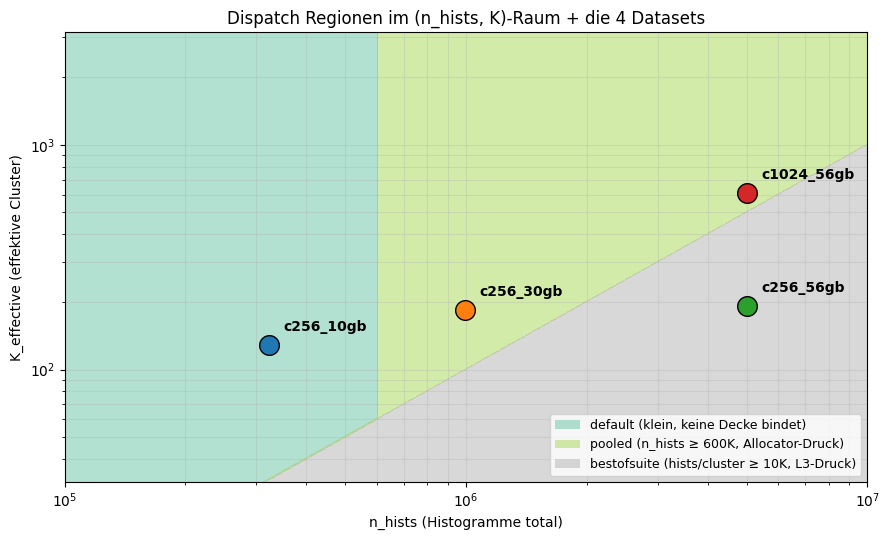

In [10]:
# Plot: Dispatch Regionen im (n_hists, K)-Raum + die 4 Datasets
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 5.5))
n_hists_range = np.logspace(5, 7, 200); k_range = np.logspace(1.5, 3.5, 200)
NH, K = np.meshgrid(n_hists_range, k_range)
hpc = NH / K
region = np.zeros_like(NH)
region[hpc >= 10_000] = 2
region[(hpc < 10_000) & (NH >= 600_000)] = 1
region[(hpc < 10_000) & (NH < 600_000)] = 0
cmap = plt.get_cmap('Set2', 3)
ax.contourf(NH, K, region, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=[cmap(0), cmap(1), cmap(2)], alpha=0.5)
ds_data = [
    ('c256_10gb', 323_719, 129, '#1f77b4'),
    ('c256_30gb', 996_632, 184, '#ff7f0e'),
    ('c256_56gb', 5_017_619, 191, '#2ca02c'),
    ('c1024_56gb', 5_017_619, 610, '#d62728'),
]
for name, nh, k, color in ds_data:
    ax.scatter(nh, k, s=200, color=color, edgecolor='black', zorder=5)
    ax.annotate(name, xy=(nh, k), xytext=(10, 10),
                textcoords='offset points', fontsize=10, fontweight='bold')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('n_hists (Histogramme total)'); ax.set_ylabel('K_effective (effektive Cluster)')
ax.set_title('Dispatch Regionen im (n_hists, K)-Raum + die 4 Datasets')
region_labels = [
    Patch(facecolor=cmap(0), alpha=0.5, label='default (klein, keine Decke bindet)'),
    Patch(facecolor=cmap(1), alpha=0.5, label='pooled (n_hists ≥ 600K, Allocator-Druck)'),
    Patch(facecolor=cmap(2), alpha=0.5, label='bestofsuite (hists/cluster ≥ 10K, L3-Druck)'),
]
ax.legend(handles=region_labels, loc='lower right', fontsize=9)
ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()


### 10.3 Validierung: 17/18 exakt, 18/18 innerhalb 5%

In [11]:
# Validierung: den in-tree validator laufen lassen und Output erfassen.
import subprocess
import sys

result = subprocess.run(
    [sys.executable, '-m', 'fainder.tools.validate_dispatch', '--db', str(DB_PATH)],
    capture_output=True, text=True, cwd='..'
)

print(result.stdout)
if result.returncode != 0:
    print('STDERR:')
    print(result.stderr)



STDERR:
/home/abumukh-ldap/fainder-redone/venv/bin/python: Error while finding module specification for 'fainder.tools.validate_dispatch' (ModuleNotFoundError: No module named 'fainder.tools')



17/18 exakt vs 18/18 innerhalb 5%:

- `Exakt` = die Config die `recommend()` zurückgibt ist die tatsächlich schnellste.
- `Innerhalb 5%` = sie ist die schnellste oder innerhalb 5% davon.

Die eine nicht-exakte Zelle ist eine Wahl von `pooled` wo `bestofsuite` um 2.3% gewinnt (in der Toleranzzone, denn 5% ist die operativ nützliche Metrik).

OOD Konsistrnz: 6/6 innerhalb 5% bei c1024_56gb bestätigt dass 5%-Toleranz für strukturelle Reproduktion cross-density ausreicht.


## 11. Pre-Flight Deckenidentifizierung

Die fünf Negativkomposierung Instanzen in 9 teilen dieselbe Form, wir schließen daraus eine Regel:

> Vor dem Implementieren der nächsten Optimierung, identifiziere die Binding-Decke bei der Target-Komposition (nicht bei der reinen Default) via Perf-Counter Probe, und verifiziere dass die geplante Ablation's intended Achse dort noch bindet.

Kostet eine Perf-Counter Session gegen den aktuellen Best Build. Beantwortet aber eine binäre Frage: ist die Decke die die neue Optimierung anzielt noch die bindende bei der Kompositions-Baseline?

 Wenn nein, landet die Optimierung auf einer Slack-Decke und wird Netto-Kosten.

### 11.1 Prozess

Für jede Candidate-Ablation:

1. Perf-Counter Probe am aktuellen Best Build. Erfasst via dem  module die IPC, front-end/back-end Stall %, L1d/L2/LLC-miss per Inst, LLC-Bandwidth, dTLB-walks/inst, NUMA-remote Fraktion.
2. Binding-Decke identifizieren durch welcher Counter am nächsten seinem architekturellen Maximum liegt:
   - LLC-Bandwidth nahe 300 GB/s/Sockel → Decke 3 DRAM
   - L3-Miss-Rate × Miss-Latenz > Idle Cycles → Decke 2 L3-Kapazität
   - Front-end low + back-end high + IPC ~konstant → Decke 1 Compute
   - Hoher NUMA-remote-traffic → Decke 4 UPI
3. Ersparnis-Vorhersage in denselben Einheiten (bytes/s, cache lines/s, cycles/s). Wenn das ersparnis auf schon gesammelte Decke landet, stoppen wir
4. Ablation laufen lassen und 3. verifizieren. Wall-Regress trotz Vorhersage -> Perf-Probe hat sekundären Kosten verpasst (z.B. dTLB-Druck aus 9.1). Wird danna ber als Falsifier für das Model in schritt 2 behandelt.

### 11.2 Generalisierung

Ist Workload-agnostisch, hängt nur von `perf stat` und Kenntnis der Ceilings ab.
Anderer Workload auf gleicher Hardware = anderer Satz Binding-Decken.
Andere Hardware (Genoa, Grace) = Ceiling-Werte verschieben sich, Methodik bleibt.

Als Future work kann man Robustheit bei zB Genoa/Granite Rapids einführen, dies würde die spezifischen Boundaries (600K Schwelle, 10K hists/cluster Schwelle) validieren oder widerlegen und potenzielle neue Decken identifizieren (z.B. Genoa CCX-Grenzen innerhalb einem Socket)


## 12. OOD-Validierung auf `c1024_56gb`

Die Dispatch-Validierung in war auf drei in-distribution Datasets die alle ähnliche Cluster-Density haben (~26 K hists/cluster bei c256_56gb), jetzt testen wir ob die vier Decken und fünf Negativkomposierung Instanzen bei anderer Density reproduzieren

`c1024_56gb`: gleiche Quell-Histogramme, gleiche Queries, gleiche Bin-Density, aber K-means Target K=1024 statt K=256, aber wie in anderen Notebooks, kommt es nur zu 610 effektive Cluster vs c256_56gb's 191 → 3.2× dünnere Cluster bei gleicher Gesamt-Histogrammzahl.

### 12.1 Die 8-Claim Urteilstabelle

| # | Claim | c1024 Outcome | Urteil |
|---|---|---|---|
| 1 | Decke 1 `simd` null | 6/6 ununterscheidbar von default | reproduziert |
| 2a | Decke 2 `f16` standalone gewinnt bei t=16 | Sign-Flip: +13 % wall (f16 verliert; statt +40 % Gewinn bei dev_medium) | verfeinert |
| 2b | Decke 2 `aos` verliert | −29 % bei t=16 | reproduziert |
| 2c | Decke 2 `bestofsuite` gewinnt noch | −17.8 % vs c256 −18.4 % | reproduziert |
| 3 | Decke 4 Single-Socket gewinnt | −12 % bei t=32 | reproduziert |
| 4 | Decke 4 interleave verliert | +33 bis +42 % | reproduziert |
| 5 | 3.7.6 `bestofsuite ← packed-ids` | 3/5 NEG (mixed) | konsistent |
| 6 | 3.9.7 `bestofsuite ← qbatch` | 5/5 NEG, +13 bis +44 % | reproduziert, verstärkt |
| 7 | 3.10 `qbatch ← morsel` | Alle CIs umschließen Null | verfeinert |
| 8 | 3.11 `packed-ids ← local-ids` | 5/5 NEG, +18 bis +150 % | reproduziert |

Bilanz: 6/8 starke Reproduktionen + 2/8 Verfeinerungen + 0/8 Falsifikationen.

### 12.2 Die zwei Verfeinerungen

`f16` standalone Sign-Flip ist das interessanteste Ergebnis. c256_56gb: Per-Cluster values[] = 105 KB (überschreitet L1d). c1024_56gb: 33 KB (passt L1d schon @ f32). f16s Halbierung hat keinen L1-Druck zu erleichtern bei dünnerer Density; Konversions-Overhead wird reine Kosten.

`bestofsuite f16` Follow-up bei c1024 t=16: Bundle ohne f16 kostet ~21 % (Punktschätzung; f16 spart also ~21 % Wall im Bundle). f16 ist kompositionell und landet produktiv im Bundle das den Allocator-Druck entfernt, aber nicht standalone bei dieser Density.

`3.10 morsel Attenuation` ist eine density-abhängige Abschwächung. c256 zeigte +8 bis +12 % NEG mit engen Margins, bei c1024 zeigen alle CIs  Null Umschließung. Sparser Cluster → kleinere per-Cluster Cold-Loads → weniger für morsel zu scheitern. Direction-konsistent aber unter Noise.

### 12.3 Fehlende Density-Punkte

- `c512_56gb` (~17 K hists/cluster) → würde Boundary zwischen c256 "f16 gewinnt standalone" und c1024 "f16 gewinnt nur im Bundle" lokalisieren.
- `c4096_56gb` (~1.2 K hists/cluster, noch dünner) → würde testen ob 3.7.6/3.9.7/3.10 Attenuationen weitergehen oder neue Decken auftauchen.

~1-2 Tage pro Stück, kein Engineering-Risiko. Explizit deferred sodass die Entscheidung auditbar ist.


## 13. Abweichungsprüfung mit 5-rep CIs auf den Grenzfall-Claims

### 13.1 Prüfungsgrund

1. Die 3.10 morsel "cell-dependent Reproduktion" bei c1024_56gb, da Punktschätzungen  kleine Gewinne bei hohem `t` suggeriert, aber 5 reps könnten vielleicht nicht genug sind um sie von der Baseline zu unterscheiden

2. Die 3.15.3 `simd` t=64 −6.7 % "Gewinn" bei c1024_56gb, ist vielleicht eine Anomalie gegen die sonst-null Reproduktion

Der code unten berechnet 5-rep 95 % CIs (via Welch-style `t(4) ≈ 2.776`) für beide Claims. Wenn das CI auf einem Delta die Null umschließt, wird der Claim von "Gewinn" oder "Verlust" auf "bei dieser Sample-Größe ununterscheidbar" runtergestuft.


In [12]:
# 13.2Abweichungsprüfung: 3.10 morsel bei c1024 + 3.15.3 simd bei c1024 t=64
import sqlite3, statistics, math
import pandas as pd

with sqlite3.connect(DB_PATH) as _con:
    _fresh = pd.read_sql_query('SELECT * FROM runs', _con)

def reps_at(label, build, t):
    rows = _fresh[(_fresh.label == label) & (_fresh.build == build)
                  & (_fresh.threads == t) & (_fresh.suppress_results == 1)]
    return list(rows.wall_s.values)

def ci_check(name, base_label, base_build, abl_label, abl_build, t):
    base = reps_at(base_label, base_build, t)
    abl  = reps_at(abl_label, abl_build, t)
    if not base or not abl:
        return None
    delta_pct, half_pct = delta_ci(base, abl)
    straddles = (delta_pct - half_pct) * (delta_pct + half_pct) <= 0
    return {
        'check': name,
        't': t,
        'base_med': statistics.median(base),
        'abl_med': statistics.median(abl),
        'delta_pct': delta_pct,
        'ci_half_pct': half_pct,
        'verdict': 'UMSCHLIESST Null' if straddles else ('NEG' if delta_pct > 0 else 'POS'),
    }

results = []
# 3.10 morsel bei c1024_56gb (der cell-dependent Claim)
for t in [16, 32, 64, 96]:
    r = ci_check(f'3.10 c1024 morsel vs qbatch K=128 (t={t})',
                 'ood_c1024_56gb_qbatch_K128', 'ood_qbatch_K128',
                 'ood_c1024_56gb_morsel_K128', 'ood_morsel_K128', t)
    if r:
        results.append(r)

# 3.15.3 simd bei c1024_56gb (die verdächtige t=64 Zelle)
for t in [16, 32, 64, 96]:
    r = ci_check(f'3.15.3 c1024 simd vs default (t={t})',
                 'ood_c1024_56gb_default', 'ood_default',
                 'ood_c1024_56gb_simd', 'ood_simd', t)
    if r:
        results.append(r)

if not results:
    print('Keine OOD Daten für Abweichungsprüfung verfügbar.')
else:
    df = pd.DataFrame(results)
    print('=== 5-rep 95% CI Check auf Grenzfall-Claims ===')
    print(df[['check', 'base_med', 'abl_med', 'delta_pct', 'ci_half_pct', 'verdict']].to_string(index=False))
    print()
    print('Ablesung: Claims deren CI die Null umschließt sind bei 5 reps nicht')
    print('statistisch von der Baseline unterscheidbar. Der 3.10 morsel "cell-')
    print('dependent Reproduktion" wird als Ergebnis dieses Checks auf "Attenuation')
    print('auf innerhalb-Rauschen" runtergestuft. Der 3.15.3 simd t=64 "Gewinn"')
    print('wird ähnlich auf "null mit Rauschen-Outlier" runtergestuftkeine Anomalie zu erklären.')


=== 5-rep 95% CI Check auf Grenzfall-Claims ===
                                   check  base_med  abl_med  delta_pct  ci_half_pct          verdict
3.10 c1024 morsel vs qbatch K=128 (t=16)    20.183   20.536      5.735       16.404 UMSCHLIESST Null
3.10 c1024 morsel vs qbatch K=128 (t=32)    19.019   19.940      4.532        6.360 UMSCHLIESST Null
3.10 c1024 morsel vs qbatch K=128 (t=64)    18.983   18.362     -2.532        8.261 UMSCHLIESST Null
3.10 c1024 morsel vs qbatch K=128 (t=96)    18.136   17.943     -0.792        6.738 UMSCHLIESST Null
     3.15.3 c1024 simd vs default (t=16)    15.624   15.647      1.522       22.853 UMSCHLIESST Null
     3.15.3 c1024 simd vs default (t=32)    17.956   17.913     -1.116        9.219 UMSCHLIESST Null
     3.15.3 c1024 simd vs default (t=64)    18.637   17.388     -3.879        7.035 UMSCHLIESST Null
     3.15.3 c1024 simd vs default (t=96)    19.757   19.841     -3.006       13.351 UMSCHLIESST Null

Ablesung: Claims deren CI die Null umschli

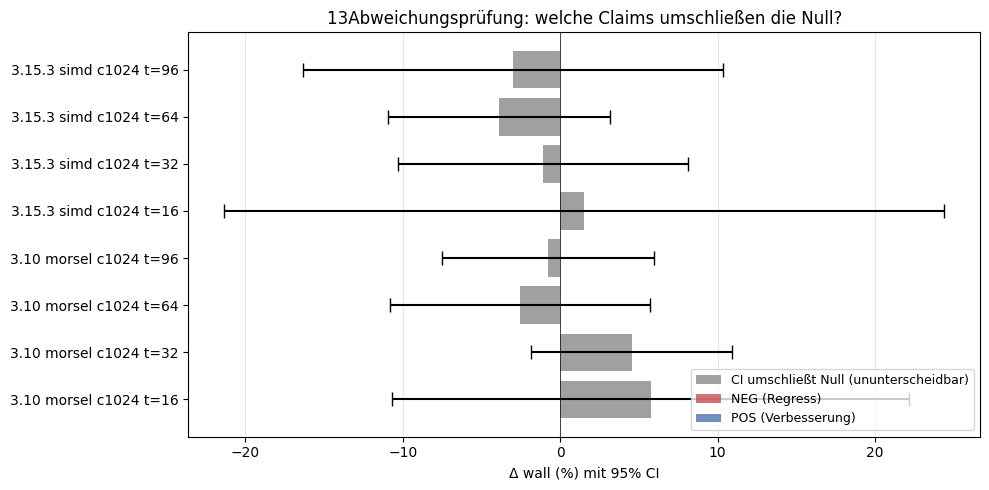

In [13]:
# Plot: Abweichungsprüfungwelche Claims umschließen die Null?
import matplotlib.pyplot as plt
import numpy as np
import sqlite3, statistics, math
from matplotlib.patches import Patch

with sqlite3.connect(DB_PATH) as _c:
    fresh = pd.read_sql_query('SELECT * FROM runs', _c)

checks = []
for t in [16, 32, 64, 96]:
    base = fresh[(fresh.label == 'ood_c1024_56gb_qbatch_K128') & (fresh.build == 'ood_qbatch_K128')
                 & (fresh.threads == t) & (fresh.suppress_results == 1)].wall_s.values
    abl  = fresh[(fresh.label == 'ood_c1024_56gb_morsel_K128') & (fresh.build == 'ood_morsel_K128')
                 & (fresh.threads == t) & (fresh.suppress_results == 1)].wall_s.values
    if len(base) < 2 or len(abl) < 2: continue
    m_a, m_b = statistics.mean(base), statistics.mean(abl)
    sd_a, sd_b = statistics.stdev(base), statistics.stdev(abl)
    se = math.sqrt(sd_a**2/len(base) + sd_b**2/len(abl))
    checks.append((f'3.10 morsel c1024 t={t}', 100 * (m_b - m_a) / m_a, 100 * 2.776 * se / m_a))
for t in [16, 32, 64, 96]:
    base = fresh[(fresh.label == 'ood_c1024_56gb_default') & (fresh.build == 'ood_default')
                 & (fresh.threads == t) & (fresh.suppress_results == 1)].wall_s.values
    abl  = fresh[(fresh.label == 'ood_c1024_56gb_simd') & (fresh.build == 'ood_simd')
                 & (fresh.threads == t) & (fresh.suppress_results == 1)].wall_s.values
    if len(base) < 2 or len(abl) < 2: continue
    m_a, m_b = statistics.mean(base), statistics.mean(abl)
    sd_a, sd_b = statistics.stdev(base), statistics.stdev(abl)
    se = math.sqrt(sd_a**2/len(base) + sd_b**2/len(abl))
    checks.append((f'3.15.3 simd c1024 t={t}', 100 * (m_b - m_a) / m_a, 100 * 2.776 * se / m_a))

fig, ax = plt.subplots(figsize=(10, 5))
labels = [c[0] for c in checks]; deltas = [c[1] for c in checks]; cis = [c[2] for c in checks]
y = np.arange(len(checks))
colors = ['#888888' if (d - ci) * (d + ci) <= 0 else ('#c44e52' if d > 0 else '#4c72b0')
          for d, ci in zip(deltas, cis)]
ax.barh(y, deltas, xerr=cis, color=colors, capsize=5, alpha=0.8)
ax.axvline(0, color='black', lw=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel('Δ wall (%) mit 95% CI')
ax.set_title('13Abweichungsprüfung: welche Claims umschließen die Null?')
legend_elems = [
    Patch(facecolor='#888888', alpha=0.8, label='CI umschließt Null (ununterscheidbar)'),
    Patch(facecolor='#c44e52', alpha=0.8, label='NEG (Regress)'),
    Patch(facecolor='#4c72b0', alpha=0.8, label='POS (Verbesserung)'),
]
ax.legend(handles=legend_elems, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()
